In [1]:
import numpy as np
from pathlib import Path
import os, json
import matplotlib.pyplot as plt
cwd = Path.cwd()
import LEAD as lead
import seaborn as sns

from groupBMC.groupBMC import GroupBMC


# Important variables
SNRs = np.array([-np.inf,-13,-11,-9,-7,-5,-3])
SubIDs = ['01','02','03','05','06','07','08','09','11','12','13','14','15','17','19','20','22','23','24','25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0)}

Active late


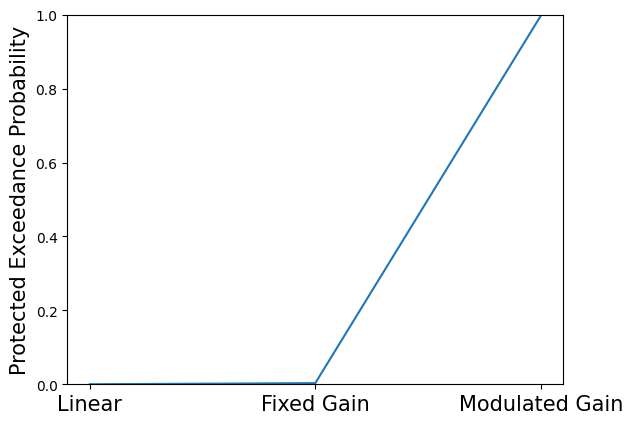

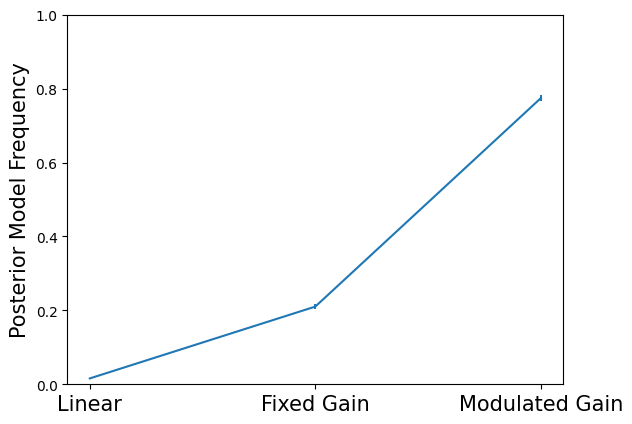

Active early


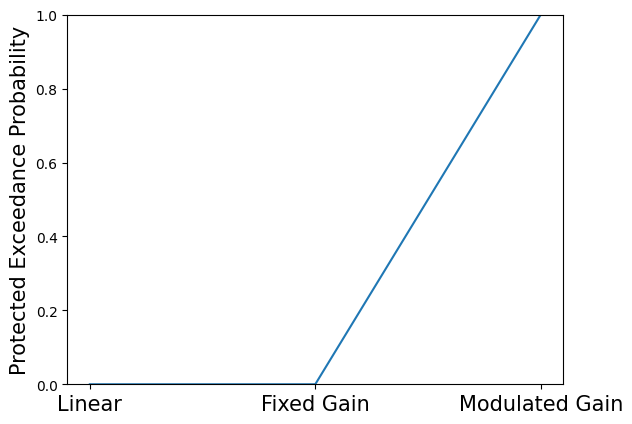

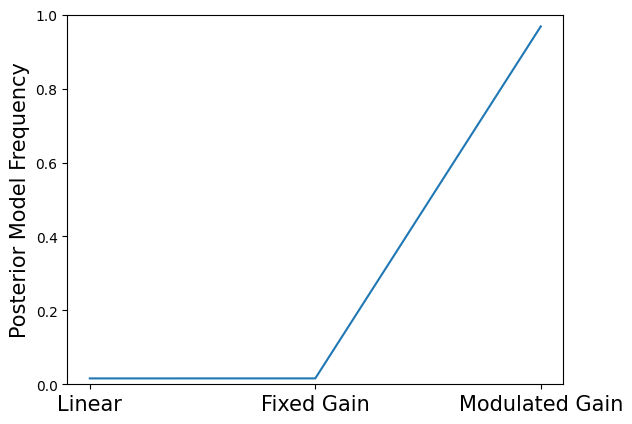

Passive late


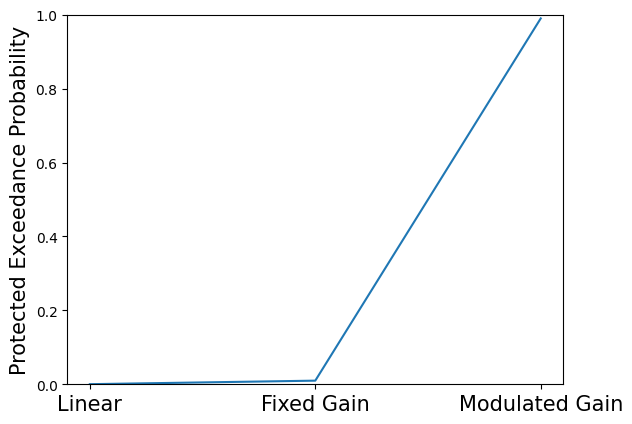

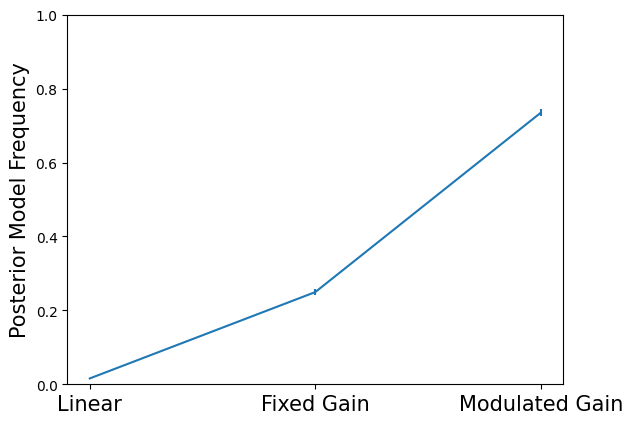

Passive early


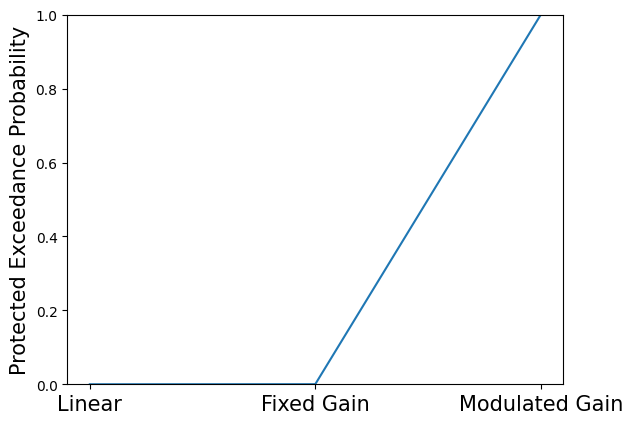

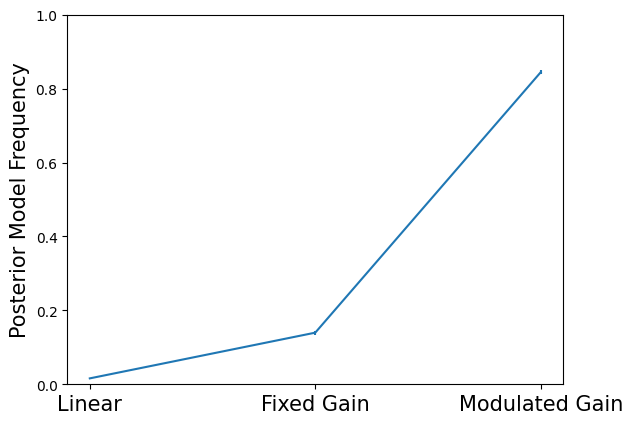

In [6]:
checkpoints = [('Active', 'late', 'Application_EEG_v2_Active_late.json'),
               ('Active', 'early', 'Application_EEG_v2_Active_early.json'),
               ('Passive', 'late', 'Application_EEG_v2_Passive_late.json'),
               ('Passive', 'early', 'Application_EEG_v2_Passive_early.json')]


for (task, stage, checkpoint_path) in checkpoints:
    print(task, stage)
     
    with open(checkpoint_path, "r") as f:
        checkpoint = json.load(f)
    detailed = checkpoint["detailed"]

    linear_ll, nonlinear_ll, gainmodul_ll = [], [], []
    for detail in detailed:
        linear_ll.append(detail['ll_linear_mean'])
        nonlinear_ll.append(detail['ll_nonlinear_mean'])
        gainmodul_ll.append(detail['ll_gainmod_mean'])
    L = np.array([linear_ll, nonlinear_ll, gainmodul_ll])

    result = GroupBMC(L).get_result()

    _, ax = plt.subplots()
    ax.plot(np.arange(len(L)), result.protected_exceedance_probability)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Linear', 'Fixed Gain', 'Modulated Gain'], fontsize=15)
    # ax.set_xlabel('Model')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Protected Exceedance Probability', fontsize=15)
    plt.savefig(f'Results_EEG_v2/{task}/{stage}/ProtectedExceedanceProbability.png')
    plt.show()


    _, ax = plt.subplots()
    ax.errorbar(np.arange(len(L)), result.frequency_mean, result.frequency_var)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Linear', 'Fixed Gain', 'Modulated Gain'], fontsize=15)
    # ax.set_xlabel('Model')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Posterior Model Frequency', fontsize=15)
    plt.savefig(f'Results_EEG_v2/{task}/{stage}/PosteriorModelFrequency.png')
    plt.show()
        

Active late


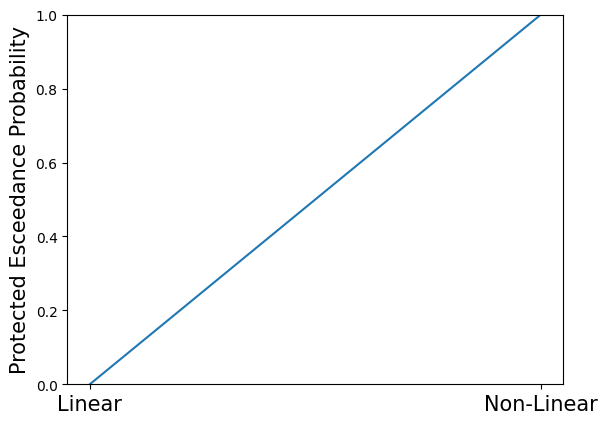

Active early


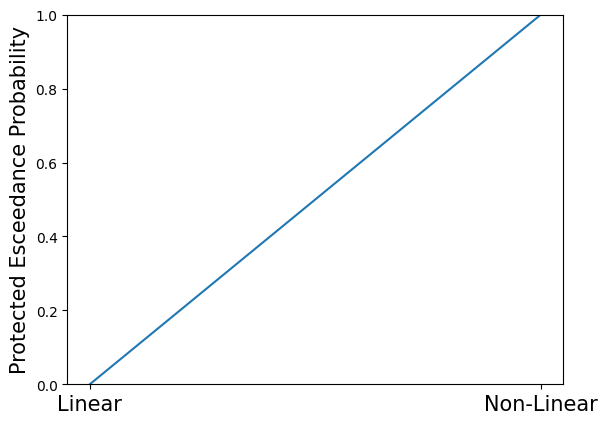

Passive late


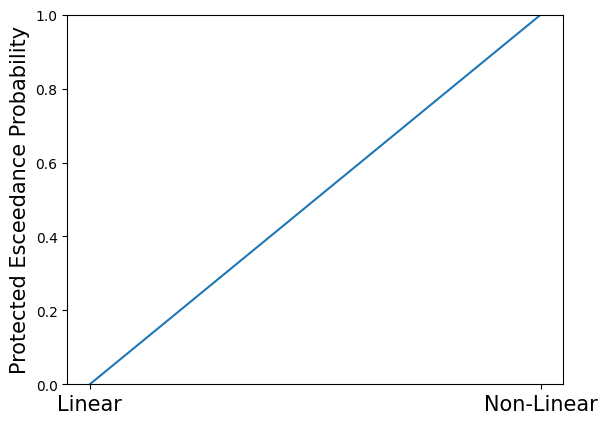

Passive early


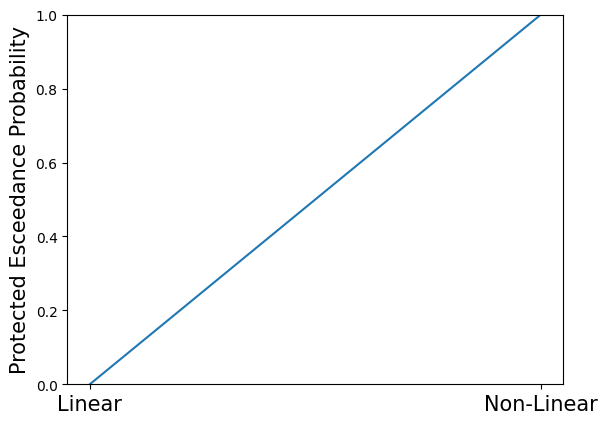

In [5]:
checkpoints = [('Active', 'late', 'Application_EEG_v2_Active_late.json'),
               ('Active', 'early', 'Application_EEG_v2_Active_early.json'),
               ('Passive', 'late', 'Application_EEG_v2_Passive_late.json'),
               ('Passive', 'early', 'Application_EEG_v2_Passive_early.json')]


for (task, stage, checkpoint_path) in checkpoints:
    print(task, stage)
     
    with open(checkpoint_path, "r") as f:
        checkpoint = json.load(f)
    detailed = checkpoint["detailed"]

    linear_ll, nonlinear_ll, gainmodul_ll = [], [], []
    for detail in detailed:
        linear_ll.append(detail['ll_linear_mean'])
        nonlinear_ll.append(detail['ll_nonlinear_mean'])
        gainmodul_ll.append(detail['ll_gainmod_mean'])
    L = np.array([linear_ll, nonlinear_ll, gainmodul_ll])

    partitions = [[1], [2, 3]]
    result = GroupBMC(L, partitions=partitions).get_result()

    _, ax = plt.subplots()
    ax.plot(np.arange(len(partitions)), result.protected_exceedance_probability)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Linear', 'Non-Linear'], fontsize=15)
    # ax.set_xlabel('Model')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Protected Esceedance Probability', fontsize=15)
    # plt.savefig(f'Results_EEG_v8/{task}/{stage}/ProtectedExceedanceProbability_Partition.png')
    plt.show()